# GR-Prediction — local monitor (LSTM + TCN/GCN)

Run this on the **laptop** while Colab trains. Reads checkpoints,
`hparams.json`, and the CSV metrics log from the Google Drive-synced
folder. Supports **all** model types: frame-rate LSTM, TCN, and GCN.

1. List all training runs + their checkpoints
2. Plot train-vs-val loss from `metrics.csv`
3. Run any checkpoint on a dry clip and see predicted GR vs ground-truth

No Colab resources are used — purely reads files synced by Google Drive.

> Requirements: `uv sync` at repo root.

In [1]:
# ── 0. Imports and defaults ─────────────────────────────────────────

import os, sys, glob, json, re, types, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import lightning as pl

warnings.filterwarnings("ignore", category=UserWarning)

# Stub rational-activations so nablafx can be imported for TCN/GCN runs.
if "rational" not in sys.modules:
    _r = types.ModuleType("rational")
    _rt = types.ModuleType("rational.torch")
    _rt.Rational = type("Rational", (torch.nn.Module,), {"forward": lambda self, x: x})
    _r.torch = _rt
    sys.modules["rational"], sys.modules["rational.torch"] = _r, _rt

from src import dsp_torch
from src.dsp_torch import (
    GR_DB_MIN, GR_DB_MAX, RMS_WINDOW,
    windowed_rms, compute_gr_target_norm, gr_norm_to_db,
)

DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp"
RUNS_DIR = "/Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs"

# Set SELECTED_RUN_NAME in the run-selection cell after available runs are listed.

SAMPLE_RATE = 44100
DEVICE = "cpu"


from eval_helpers import _checkpoint_sort_key, latest_best_checkpoint, list_runs


print(f"torch {torch.__version__}  |  device: {DEVICE}")
print(f"Shared GR DSP helpers: {dsp_torch.__file__}")

/Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.10.0  |  device: cpu
Shared GR DSP helpers: /Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/src/dsp_torch.py


In [2]:
# ── 1. List available LSTM runs ──────────────────────────────────────

assert RUNS_DIR and os.path.isdir(RUNS_DIR), f"RUNS_DIR not found: {RUNS_DIR}"

runs_df = list_runs(RUNS_DIR)
assert not runs_df.empty, "No runs found yet."

available_models_df = runs_df[runs_df["type"] == "frame_rate_lstm"].copy()
assert not available_models_df.empty, "No frame-rate LSTM runs found."

display_cols = ["run", "type", "epoch", "best_val", "n_ckpts", "eval_ckpt", "modified"]
print(f"Available LSTM runs: {len(available_models_df)}")
display(available_models_df[display_cols])

Available LSTM runs: 2


,run,type,epoch,best_val,n_ckpts,eval_ckpt,modified
13,lstm_gr_20260507_172935_lstm_v1,frame_rate_lstm,143.0,0.001403,32,best-056-3021.ckpt,2026-05-26 11:57:49.811913967
14,lstm_gr_20260507_190047_lstm_v2,frame_rate_lstm,75.0,0.593050,19,best-028-1537.ckpt,2026-05-26 11:57:49.946328163


In [3]:
# ── 2. Select run and checkpoint ─────────────────────────────────────

SELECTED_RUN_NAME = "lstm_gr_20260507_190047_lstm_v2"

matches = available_models_df[available_models_df["run"] == SELECTED_RUN_NAME]
assert len(matches) == 1, f"Run not found in available LSTM runs: {SELECTED_RUN_NAME}"
selected_run = matches.iloc[0]

RUN_NAME = str(selected_run["run"])
RUN_DIR = os.path.join(RUNS_DIR, RUN_NAME)
CKPT_DIR = os.path.join(RUN_DIR, "checkpoints")
HPARAMS_PATH = os.path.join(RUN_DIR, "hparams.json")
EVAL_CKPT_PATH = latest_best_checkpoint(RUN_DIR)

print(f"Selected run   : {RUN_NAME}")
print(f"Model type     : {selected_run['type']}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
if pd.notna(selected_run.get("best_val")):
    print(f"Best val loss  : {selected_run['best_val']:.6f}")

Selected run   : lstm_gr_20260507_190047_lstm_v2
Model type     : frame_rate_lstm
Eval checkpoint: best-028-1537.ckpt
Best val loss  : 0.593050


In [4]:
# ── 2. Inspect checkpoints ──────────────────────────────────────────

print(f"Selected run   : {RUN_NAME}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
print("Checkpoints    :")
for c in sorted(glob.glob(os.path.join(CKPT_DIR, "*.ckpt")), key=_checkpoint_sort_key):
    marker = " <-- eval" if os.path.abspath(c) == os.path.abspath(EVAL_CKPT_PATH) else ""
    sz = os.path.getsize(c) / 1e6
    print(f"  {os.path.basename(c):<36}  {sz:6.2f} MB{marker}")

Selected run   : lstm_gr_20260507_190047_lstm_v2
Eval checkpoint: best-028-1537.ckpt
Checkpoints    :
  last.ckpt                               0.99 MB
  epoch-004.ckpt                          0.99 MB
  epoch-009.ckpt                          0.99 MB
  epoch-014.ckpt                          0.99 MB
  epoch-019.ckpt                          0.99 MB
  epoch-024.ckpt                          0.99 MB
  best-025-1378.ckpt                      0.99 MB
  best-026-1431.ckpt                      0.99 MB
  best-028-1537.ckpt                      0.99 MB <-- eval
  epoch-029.ckpt                          0.99 MB
  epoch-034.ckpt                          0.99 MB
  epoch-039.ckpt                          0.99 MB
  epoch-044.ckpt                          0.99 MB
  epoch-049.ckpt                          0.99 MB
  epoch-054.ckpt                          0.99 MB
  epoch-059.ckpt                          0.99 MB
  epoch-064.ckpt                          0.99 MB
  epoch-069.ckpt                       

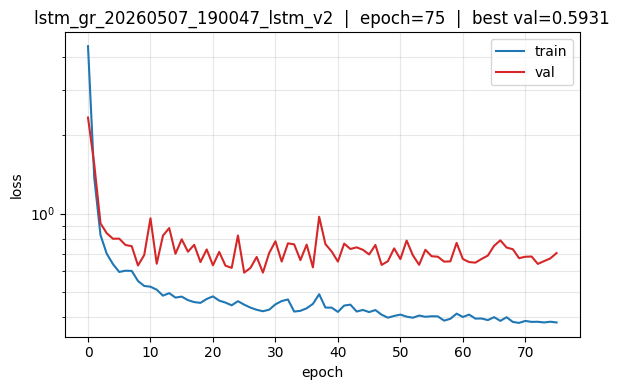

In [5]:
# ── 3. Loss curves ──────────────────────────────────────────────────

from eval_helpers import plot_loss_curves

_ = plot_loss_curves(RUN_DIR)

In [6]:
# ── 4. Model definitions & checkpoint loading ───────────────────────
# Handles frame_rate_lstm, tcn, and gcn model types.

# ── LSTM (defined inline, matches train_lstm_nocond.ipynb) ───────────

class FrameRateLSTMGR(nn.Module):
    def __init__(
        self,
        hop_size: int = 256,
        encoder_channels: int = 32,
        hidden_size: int = 64,
        num_layers: int = 2,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.hop_size = hop_size
        self.rf = hop_size * 4
        ks = hop_size * 2
        self.encoder = nn.Sequential(
            nn.Conv1d(1, encoder_channels, ks, stride=hop_size, padding=ks // 2),
            nn.PReLU(encoder_channels),
            nn.Conv1d(encoder_channels, encoder_channels, 3, padding=1),
            nn.PReLU(encoder_channels),
        )
        self.lstm = nn.LSTM(
            encoder_channels, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        T = x.shape[-1]
        feat = self.encoder(x)
        feat = feat.transpose(1, 2)
        h, _ = self.lstm(feat)
        gr = self.head(h)
        gr = gr.transpose(1, 2)
        gr = F.interpolate(gr, size=T, mode="linear", align_corners=False)
        return torch.tanh(gr)

    def reset_states(self):
        pass


# ── LSTM Lightning system (matches train_lstm_nocond.ipynb) ──────────

class GRPredictionLSTM(pl.LightningModule):
    def __init__(self, model, lr=1e-3, diff_weight=0.3, rms_window=RMS_WINDOW,
                 lr_patience=20, min_lr=1e-6):
        super().__init__()
        self.model = model
        self.lr = lr
        self.diff_weight = diff_weight
        self.rms_window = rms_window
        self.lr_patience = lr_patience
        self.min_lr = min_lr

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr)
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode="min", factor=0.5, patience=self.lr_patience, min_lr=self.min_lr,
        )
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sched, "monitor": "loss/val"}}


# ── TCN/GCN Lightning system (matches train_gcn_nocond.ipynb) ────────

class GRPredictionSystem(pl.LightningModule):
    def __init__(self, processor, lr=1e-3, diff_weight=0.1, smooth_weight=0.2,
                 lr_patience=20, min_lr=1e-5, rms_window=RMS_WINDOW, output_tanh=False):
        super().__init__()
        self.processor = processor
        self.lr = lr
        self.diff_weight = diff_weight
        self.smooth_weight = smooth_weight
        self.lr_patience = lr_patience
        self.min_lr = min_lr
        self.rms_window = rms_window
        self.output_tanh = output_tanh

    def forward(self, x):
        out = self.processor(x)
        if getattr(self, "output_tanh", False):
            out = torch.tanh(out)
        return out

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr)
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode="min", factor=0.5, patience=self.lr_patience, min_lr=self.min_lr,
        )
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sched, "monitor": "loss/val"}}


# ── Model builders ───────────────────────────────────────────────────

def build_lstm_from_hparams(hp: dict) -> FrameRateLSTMGR:
    h = hp["lstm"]
    return FrameRateLSTMGR(
        hop_size=h["hop_size"],
        encoder_channels=h["encoder_channels"],
        hidden_size=h["hidden_size"],
        num_layers=h["num_layers"],
        dropout=h.get("dropout", 0.0),
    )


def build_tcn_from_hparams(hp: dict):
    from nablafx.processors import TCN
    t = hp["tcn"]
    return TCN(
        num_inputs=1, num_outputs=1, num_controls=0,
        num_blocks=t["num_blocks"], stack_size=t.get("stack_size", t["num_blocks"]),
        kernel_size=t["kernel_size"], dilation_growth=t["dilation_growth"],
        channel_width=t["channel_width"], causal=t["causal"],
        cond_type=None, bias=t["bias"], batchnorm=t["batchnorm"],
        act_type=t.get("act_type", "tanh"),
    )


def build_gcn_from_hparams(hp: dict):
    from nablafx.processors import GCN
    g = hp["gcn"]
    return GCN(
        num_inputs=1, num_outputs=1, num_controls=0,
        num_blocks=g["num_blocks"], stack_size=g.get("stack_size", g["num_blocks"]),
        kernel_size=g["kernel_size"], dilation_growth=g["dilation_growth"],
        channel_width=g["channel_width"], causal=g["causal"],
        cond_type=None, bias=g["bias"], batchnorm=g["batchnorm"],
        residual=g.get("residual", False), direct_path=g.get("direct_path", False),
    )


# ── Unified checkpoint loader ────────────────────────────────────────

from eval_helpers import _find_hparams_json


def load_system_from_ckpt(ckpt_path: str, hparams_path: str | None = None):
    if hparams_path is None:
        hparams_path = _find_hparams_json(ckpt_path)
    assert hparams_path and os.path.isfile(hparams_path), (
        f"hparams.json not found near {ckpt_path}"
    )
    with open(hparams_path) as f:
        hp = json.load(f)

    expected_hash = hp.get("src_dsp_torch_sha256")
    if expected_hash:
        import hashlib as _hl
        local_hash = _hl.sha256(Path(dsp_torch.__file__).read_bytes()).hexdigest()
        if local_hash != expected_hash:
            print("[warning] local src.dsp_torch differs from checkpoint's version")

    model_type = hp.get("model_type", "tcn")

    if model_type == "frame_rate_lstm":
        model = build_lstm_from_hparams(hp)
        system = GRPredictionLSTM.load_from_checkpoint(
            ckpt_path, model=model, map_location=DEVICE,
            rms_window=hp.get("rms_window", RMS_WINDOW),
            lr_patience=hp.get("lr_plateau_patience", 20),
        )
    elif model_type == "gcn":
        processor = build_gcn_from_hparams(hp)
        system = GRPredictionSystem.load_from_checkpoint(
            ckpt_path, processor=processor, map_location=DEVICE,
            rms_window=hp.get("rms_window", RMS_WINDOW),
            lr_patience=hp.get("lr_plateau_patience", 20),
            output_tanh=True,
        )
    else:
        processor = build_tcn_from_hparams(hp)
        system = GRPredictionSystem.load_from_checkpoint(
            ckpt_path, processor=processor, map_location=DEVICE,
            rms_window=hp.get("rms_window", RMS_WINDOW),
            lr_patience=hp.get("lr_plateau_patience", 20),
            output_tanh=False,
        )

    system.to(DEVICE)
    system.eval()
    return system, hp


print("Model builders registered: frame_rate_lstm, tcn, gcn")

Model builders registered: frame_rate_lstm, tcn, gcn


In [7]:
# ── 5. Evaluation & visualisation functions ──────────────────────────

def same_setting_pairs(data_root: str, setting: str) -> list[tuple[str, str]]:
    dry_dir = os.path.join(data_root, "processed_normalized")
    wet_dir = os.path.join(data_root, "processed_ground_truth", setting)
    assert os.path.isdir(dry_dir), f"Missing: {dry_dir}"
    assert os.path.isdir(wet_dir), f"Missing: {wet_dir}"
    dry_lookup = {
        os.path.basename(p).replace("_UnmasteredWAV.wav", ""): p
        for p in sorted(glob.glob(os.path.join(dry_dir, "*_UnmasteredWAV.wav")))
    }
    pairs = []
    for wet_path in sorted(glob.glob(os.path.join(wet_dir, "*-exported.wav"))):
        song = os.path.basename(wet_path).replace("-exported.wav", "")
        if song in dry_lookup:
            pairs.append((dry_lookup[song], wet_path))
    assert pairs, f"No pairs for {setting}"
    return pairs


from eval_helpers import _read_dry_wet_segment, same_setting_pairs


@torch.no_grad()
def predict_gr_curves(
    ckpt_path: str,
    dry_wav_path: str,
    wet_wav_path: str,
    start_sec: float = 0.0,
    duration_sec: float = 6.0,
    hparams_path: str | None = None,
    pre_roll_sec: float | None = None,
):
    system, hp = load_system_from_ckpt(ckpt_path, hparams_path)
    sr = int(hp["sample_rate"])
    rms_win = int(hp["rms_window"])
    model_type = hp.get("model_type", "tcn")

    start = int(round(start_sec * sr))
    stop = start + int(round(duration_sec * sr))

    if model_type == "frame_rate_lstm":
        rf_samples = hp["lstm"].get("hop_size", 256) * 4
    else:
        key = "gcn" if model_type == "gcn" else "tcn"
        rf_samples = int(hp.get(key, {}).get("rf_samples", 0))
        if rf_samples == 0:
            inner = getattr(system, "processor", getattr(system, "model", None))
            rf_samples = int(getattr(inner, "rf", 0))

    pre_roll = rf_samples if pre_roll_sec is None else int(round(pre_roll_sec * sr))
    context_start = max(0, start - pre_roll)
    context_offset = start - context_start

    dry, wet = _read_dry_wet_segment(dry_wav_path, wet_wav_path, context_start, stop, sr)
    gr_target_norm = compute_gr_target_norm(dry, wet, rms_win).cpu()

    x = dry.unsqueeze(0).to(DEVICE)
    inner = getattr(system, "processor", getattr(system, "model", None))
    if hasattr(inner, "reset_states"):
        inner.reset_states()
    gr_pred_norm = system(x).squeeze().detach().cpu()

    n = min(stop - start, dry.shape[-1] - context_offset,
            gr_target_norm.shape[-1] - context_offset,
            gr_pred_norm.shape[-1] - context_offset)
    assert n > 0
    w = slice(context_offset, context_offset + n)

    gr_true = gr_norm_to_db(gr_target_norm[..., w]).squeeze().numpy()
    gr_pred = gr_norm_to_db(gr_pred_norm[..., w]).squeeze().numpy()
    dry_wave = dry[..., w].squeeze().cpu().numpy()
    err = gr_pred - gr_true
    song = os.path.basename(dry_wav_path).replace("_UnmasteredWAV.wav", "")

    return {
        "song": song, "setting": hp["setting"], "model_type": model_type,
        "ckpt": ckpt_path, "sample_rate": sr,
        "start_sec": start_sec, "duration_sec": n / sr,
        "pre_roll_sec": context_offset / sr,
        "time": np.arange(n) / sr,
        "dry": dry_wave, "gr_true": gr_true, "gr_pred": gr_pred,
        "error": err,
        "mae_db": float(np.mean(np.abs(err))),
        "rmse_db": float(np.sqrt(np.mean(err ** 2))),
        "hparams": hp,
    }


@torch.no_grad()
def visualize_prediction(
    ckpt_path: str,
    dry_wav_path: str | None = None,
    wet_wav_path: str | None = None,
    start_sec: float = 0.0,
    duration_sec: float = 6.0,
    hparams_path: str | None = None,
    pre_roll_sec: float | None = None,
    title: str | None = None,
):
    system, hp = load_system_from_ckpt(ckpt_path, hparams_path)
    setting = hp["setting"]
    pairs = same_setting_pairs(DATA_ROOT, setting)
    if dry_wav_path is None:
        dry_wav_path, wet_wav_path = pairs[0]
    elif wet_wav_path is None:
        song = os.path.basename(dry_wav_path).replace("_UnmasteredWAV.wav", "")
        wet_wav_path = os.path.join(DATA_ROOT, "processed_ground_truth", setting, f"{song}-exported.wav")

    curves = predict_gr_curves(
        ckpt_path=ckpt_path, dry_wav_path=dry_wav_path, wet_wav_path=wet_wav_path,
        start_sec=start_sec, duration_sec=duration_sec,
        hparams_path=hparams_path, pre_roll_sec=pre_roll_sec,
    )

    t = curves["time"]
    fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True,
                             gridspec_kw={"height_ratios": [1, 2, 1]})
    axes[0].plot(t, curves["dry"], lw=0.6, color="#444")
    axes[0].set_ylabel("dry")
    axes[0].set_ylim(-1.05, 1.05)
    axes[0].grid(alpha=0.3)

    axes[1].plot(t, curves["gr_true"], label="target", lw=1.4, color="#1f77b4")
    axes[1].plot(t, curves["gr_pred"], label="prediction", lw=1.2, color="#d62728", alpha=0.85)
    axes[1].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[1].set_ylabel("Gain reduction (dB)")
    axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)

    axes[2].plot(t, curves["error"], lw=0.8, color="#2ca02c")
    axes[2].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[2].set_ylabel("error (dB)")
    axes[2].set_xlabel("time (s)")
    axes[2].grid(alpha=0.3)

    ttl = title or (
        f"{curves['song']}  |  {curves['model_type']}  |  {setting}\n"
        f"ckpt={os.path.basename(ckpt_path)}  "
        f"pre-roll={curves['pre_roll_sec']:.2f}s  "
        f"MAE={curves['mae_db']:.2f} dB  RMSE={curves['rmse_db']:.2f} dB"
    )
    fig.suptitle(ttl, fontsize=10)
    plt.tight_layout()
    plt.show()
    return curves


def compare_same_setting_curves(
    ckpt_path: str,
    start_sec: float = 30.0,
    duration_sec: float = 5.0,
    max_pairs: int = 2,
    start_pair: int = 5,
    hparams_path: str | None = None,
):
    _, hp = load_system_from_ckpt(ckpt_path, hparams_path)
    pairs = same_setting_pairs(DATA_ROOT, hp["setting"])
    selected = pairs[start_pair:max_pairs + start_pair]
    print(f"Comparing {len(selected)} of {len(pairs)} pairs — {hp.get('model_type', '?')} model")
    return [
        visualize_prediction(
            ckpt_path=ckpt_path, dry_wav_path=d, wet_wav_path=w,
            start_sec=start_sec, duration_sec=duration_sec,
            hparams_path=hparams_path,
        )
        for d, w in selected
    ]

## Usage

Re-run the cells below any time; they read the latest synced files from Drive.
Use the available-runs cell first, then set `SELECTED_RUN_NAME` in the following selection cell.

Running best-028-1537.ckpt
[warning] local src.dsp_torch differs from checkpoint's version
[warning] local src.dsp_torch differs from checkpoint's version


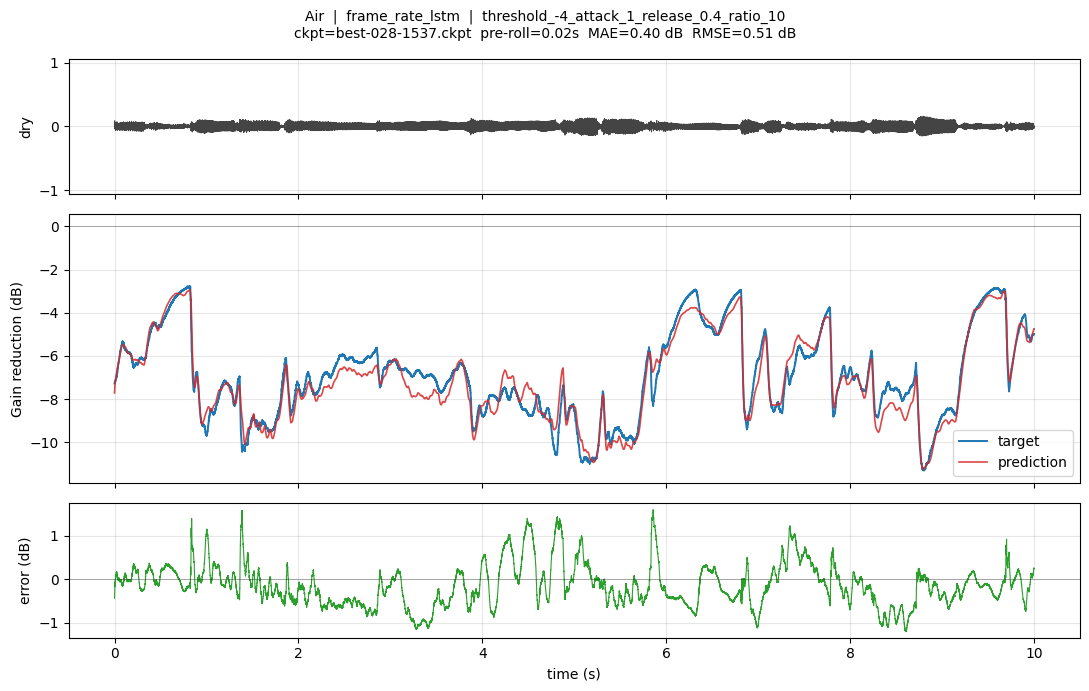

In [8]:
# Single prediction preview
print(f"Running {os.path.basename(EVAL_CKPT_PATH)}")

_ = visualize_prediction(
    ckpt_path=EVAL_CKPT_PATH,
    start_sec=30.0,
    duration_sec=10.0,
)

[warning] local src.dsp_torch differs from checkpoint's version
Comparing 3 of 10 pairs — frame_rate_lstm model
[warning] local src.dsp_torch differs from checkpoint's version
[warning] local src.dsp_torch differs from checkpoint's version


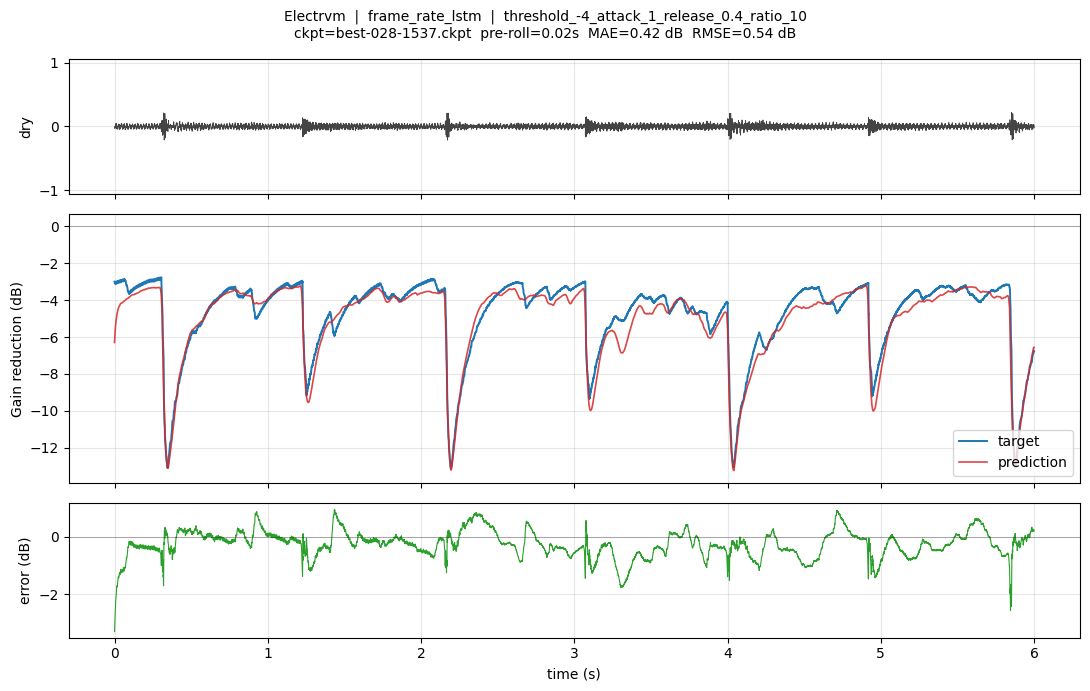

[warning] local src.dsp_torch differs from checkpoint's version
[warning] local src.dsp_torch differs from checkpoint's version


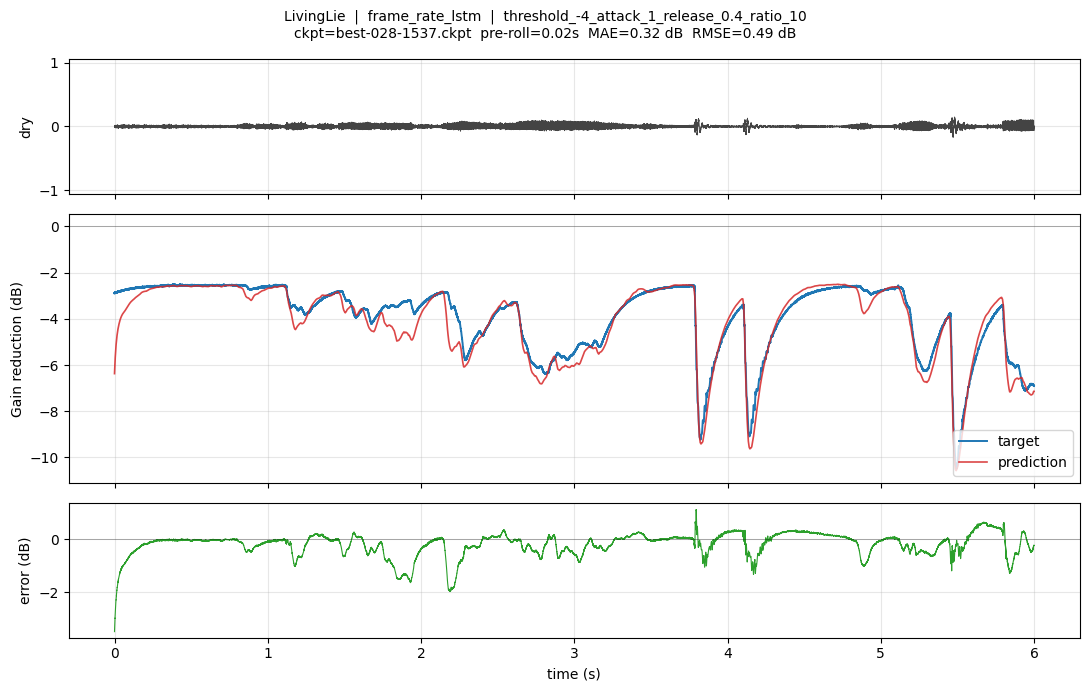

[warning] local src.dsp_torch differs from checkpoint's version
[warning] local src.dsp_torch differs from checkpoint's version


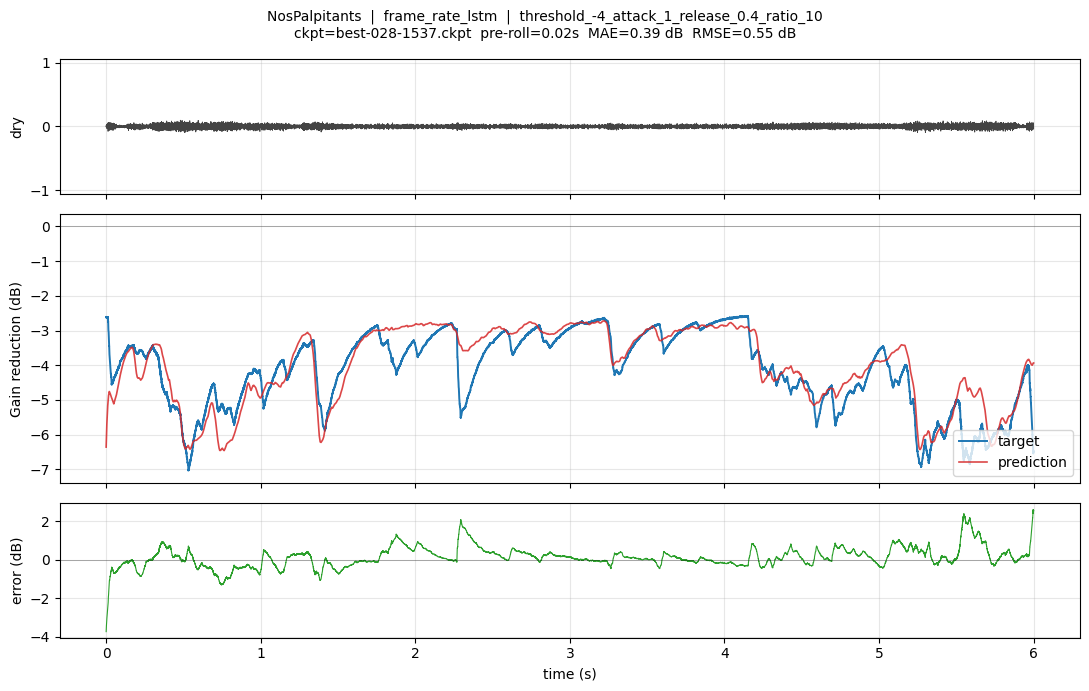

In [9]:
# Compare across multiple songs
results = compare_same_setting_curves(
    ckpt_path=EVAL_CKPT_PATH,
    start_sec=20.0,
    duration_sec=6.0,
    max_pairs=3,
)

In [10]:
# Validation-set reconstructed audio metrics (chunked, memory-friendly)
#
# Reconstructs the same song-level validation split used during training,
# predicts GR in chunks, reconstructs wet audio as dry * 10 ** (GR_dB / 20),
# computes metrics per chunk, then reports one duration-weighted validation row.

import gc
from pathlib import Path

import pandas as pd
import soundfile as sf
import torch

from src.losses import compute_all_losses as compute_audio_losses


def _db_to_amplitude(db: torch.Tensor) -> torch.Tensor:
    return torch.pow(10.0, db / 20.0)


def _model_inner(system):
    return getattr(system, "processor", getattr(system, "model", None))


def _model_rf_samples(system, hp: dict) -> int:
    model_type = hp.get("model_type", "tcn")
    if model_type == "frame_rate_lstm":
        return int(hp.get("lstm", {}).get("hop_size", 256)) * 4

    key = "gcn" if model_type == "gcn" else "tcn"
    rf_samples = int(hp.get(key, {}).get("rf_samples", 0) or 0)
    if rf_samples == 0:
        rf_samples = int(getattr(_model_inner(system), "rf", 0) or 0)
    return rf_samples


@torch.no_grad()
def _predict_segment_gr(
    system,
    hp: dict,
    dry_context: torch.Tensor,
    context_offset: int,
    target_len: int,
    device: torch.device,
) -> torch.Tensor:
    inner = _model_inner(system)
    if hasattr(inner, "reset_states"):
        inner.reset_states()

    x = dry_context.unsqueeze(0).to(device)
    with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
        gr_context_norm = system(x)
        gr_context_db = gr_norm_to_db(gr_context_norm).clamp(GR_DB_MIN, GR_DB_MAX)

    start = context_offset
    stop = context_offset + target_len
    return gr_context_db.squeeze(0)[..., start:stop].float().cpu()


def _pair_num_frames(dry_path: str, wet_path: str, sr: int) -> int:
    dry_info = sf.info(dry_path)
    wet_info = sf.info(wet_path)
    if dry_info.samplerate != sr or wet_info.samplerate != sr:
        print(
            f"[warning] {Path(dry_path).stem}: expected {sr} Hz, "
            f"got dry={dry_info.samplerate}, wet={wet_info.samplerate}; "
            "segment offsets assume matching sample rates."
        )
    return min(dry_info.frames, wet_info.frames)


def _song_from_dry_path(dry_path: str) -> str:
    return Path(dry_path).name.replace("_UnmasteredWAV.wav", "")


def _validation_pairs_from_training_split(
    all_pairs: list[tuple[str, str]],
    hp: dict,
) -> list[tuple[str, str]]:
    songs = sorted({_song_from_dry_path(dry_path) for dry_path, _ in all_pairs})
    split_seed = int(hp.get("split_seed", 42))
    train_split = float(hp.get("train_split", 0.8))

    generator = torch.Generator().manual_seed(split_seed)
    perm = torch.randperm(len(songs), generator=generator).tolist()
    n_train = int(len(songs) * train_split)
    n_train = min(max(1, n_train), len(songs) - 1)

    train_songs = {songs[i] for i in perm[:n_train]}
    val_songs = set(songs) - train_songs

    print(
        f"Validation split: {len(val_songs)} validation songs, "
        f"{len(train_songs)} train songs (seed={split_seed}, train_split={train_split})"
    )
    print(f"Validation songs: {sorted(val_songs)}")

    return [
        (dry_path, wet_path)
        for dry_path, wet_path in all_pairs
        if _song_from_dry_path(dry_path) in val_songs
    ]


from eval_helpers import (
    _db_to_amplitude,
    _pair_num_frames,
    _song_from_dry_path,
    _validation_pairs_from_training_split,
    _weighted_average_metric_rows,
)


# Leave as None to evaluate the full validation split. Use a small integer for
# a quick smoke test, or list validation song names for a subset.
MAX_VALIDATION_SONGS: int | None = None
EVAL_VALIDATION_SONGS: list[str] | None = None

# Smaller chunks reduce peak memory. Increase if you want faster evaluation and
# have RAM/VRAM headroom. None for pre-roll uses the model receptive field.
WHOLE_SONG_CHUNK_SEC = 10.0
WHOLE_SONG_PRE_ROLL_SEC = None
SAVE_CHUNK_METRICS = False

system, hp = load_system_from_ckpt(EVAL_CKPT_PATH, HPARAMS_PATH)
sr = int(hp["sample_rate"])
device = torch.device(DEVICE)
chunk_frames = int(round(WHOLE_SONG_CHUNK_SEC * sr))
pre_roll_frames = _model_rf_samples(system, hp) if WHOLE_SONG_PRE_ROLL_SEC is None else int(round(WHOLE_SONG_PRE_ROLL_SEC * sr))
metric_cols = ["MAE (L1)", "MSE (L2)", "ESR", "MR-STFT", "EDC", "M_NRMSE", "M_SF"]

all_pairs = same_setting_pairs(DATA_ROOT, hp["setting"])
eval_pairs = _validation_pairs_from_training_split(all_pairs, hp)

if EVAL_VALIDATION_SONGS is not None:
    selected_names = set(EVAL_VALIDATION_SONGS)
    eval_pairs = [
        (dry_path, wet_path)
        for dry_path, wet_path in eval_pairs
        if _song_from_dry_path(dry_path) in selected_names
    ]

if MAX_VALIDATION_SONGS is not None:
    eval_pairs = eval_pairs[:MAX_VALIDATION_SONGS]

assert eval_pairs, "No validation pairs selected for evaluation."

validation_chunk_rows = []
for song_idx, (dry_path, wet_path) in enumerate(eval_pairs, start=1):
    song = _song_from_dry_path(dry_path)
    total_frames = _pair_num_frames(dry_path, wet_path, sr)
    print(
        f"[{song_idx}/{len(eval_pairs)}] Evaluating validation song {song} "
        f"({total_frames / sr:.1f}s, chunks of {WHOLE_SONG_CHUNK_SEC:.1f}s)"
    )

    for chunk_idx, start in enumerate(range(0, total_frames, chunk_frames), start=1):
        stop = min(start + chunk_frames, total_frames)
        context_start = max(0, start - pre_roll_frames)
        context_offset = start - context_start

        dry_context, wet_context = _read_dry_wet_segment(
            dry_path,
            wet_path,
            context_start,
            stop,
            sr,
        )
        target_len = min(
            stop - start,
            dry_context.shape[-1] - context_offset,
            wet_context.shape[-1] - context_offset,
        )
        if target_len <= 0:
            continue

        dry_chunk = dry_context[..., context_offset : context_offset + target_len]
        wet_chunk = wet_context[..., context_offset : context_offset + target_len]
        gr_pred_db = _predict_segment_gr(
            system,
            hp,
            dry_context,
            context_offset,
            target_len,
            device,
        )
        pred_wet = dry_chunk * _db_to_amplitude(gr_pred_db)

        losses = compute_audio_losses(pred_wet.unsqueeze(0), wet_chunk.unsqueeze(0))
        validation_chunk_rows.append({
            "Song": song,
            "Chunk": chunk_idx,
            "Start (s)": start / sr,
            "Duration (s)": target_len / sr,
            "Frames": target_len,
            **losses,
        })

        del dry_context, wet_context, dry_chunk, wet_chunk, gr_pred_db, pred_wet
        if device.type == "cuda":
            torch.cuda.empty_cache()

    gc.collect()

assert validation_chunk_rows, "No validation chunks were evaluated."

weighted_metrics = _weighted_average_metric_rows(validation_chunk_rows, metric_cols)
total_frames = sum(row["Frames"] for row in validation_chunk_rows)
validation_metrics_df = pd.DataFrame([
    {
        "Split": "validation",
        "Songs": len(eval_pairs),
        "Chunks": len(validation_chunk_rows),
        "Duration (s)": total_frames / sr,
        **weighted_metrics,
    }
])

validation_metrics_path = Path(RUN_DIR) / "eval_audio_metrics_validation.csv"
validation_metrics_df.to_csv(validation_metrics_path, index=False)
print(f"Saved validation audio metrics -> {validation_metrics_path}")

if SAVE_CHUNK_METRICS:
    chunk_metrics_path = Path(RUN_DIR) / "eval_audio_metrics_validation_chunks.csv"
    pd.DataFrame(validation_chunk_rows).to_csv(chunk_metrics_path, index=False)
    print(f"Saved validation chunk audio metrics -> {chunk_metrics_path}")

display(validation_metrics_df)

[warning] local src.dsp_torch differs from checkpoint's version
Validation split: 2 validation songs, 8 train songs (seed=42, train_split=0.8)
Validation songs: ['Borderline', 'NosPalpitants']
[1/2] Evaluating validation song Borderline (273.9s, chunks of 10.0s)
[2/2] Evaluating validation song NosPalpitants (198.1s, chunks of 10.0s)
Saved validation audio metrics -> /Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs/lstm_gr_20260507_190047_lstm_v2/eval_audio_metrics_validation.csv


,Split,Songs,Chunks,Duration (s),MAE (L1),MSE (L2),ESR,MR-STFT,EDC,M_NRMSE,M_SF
0,validation,2,48,471.969365,0.001692,0.000007,0.03106,0.082849,0.207258,0.103705,0.13434
